In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('Libraries loaded.')
print('pandas', pd.__version__, '| numpy', np.__version__, '| seaborn', sns.__version__)

Libraries loaded.
pandas 2.3.3 | numpy 2.2.6 | seaborn 0.13.2


In [ ]:
DATA_PATH = '/INFO-VIZ/attacks.csv'

raw = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
raw.head(3)

Raw shape: 25,723 rows x 24 columns


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,57,"No injury to occupant, outrigger canoe and paddle damaged",N,18h00,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.25-Wolfe.pdf,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,11,Minor injury to left thigh,N,14h00 -15h00,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.18-McNeely.pdf,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,48,Injury to left lower leg from surfboard skeg,N,07h45,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_directory/2018.06.09-Denges.pdf,2018.06.09,2018.06.09,6301.0,NaN,NaN


In [3]:
print('Columns and dtypes:')
print(raw.dtypes)

Columns and dtypes:
Case Number                object
Date                       object
Year                      float64
Type                       object
Country                    object
Area                       object
Location                   object
Activity                   object
Name                       object
Sex                        object
Age                        object
Injury                     object
Fatal (Y/N)                object
Time                       object
Species                    object
Investigator or Source     object
pdf                        object
href formula               object
href                       object
Case Number.1              object
Case Number.2              object
original order            float64
Unnamed: 22                object
Unnamed: 23                object
dtype: object


In [ ]:
df = raw.copy()


df.columns = [c.strip() for c in df.columns]

drop_cols = ['Case Number.1', 'Case Number.2', 'Unnamed: 22', 'Unnamed: 23',
             'pdf', 'href formula', 'href', 'original order']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

before = len(df)
df = df.dropna(how='all').reset_index(drop=True)
print(f'Dropped {before - len(df):,} fully empty rows -> {len(df):,} remaining.')

str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})

df.head(3)

Dropped 17,020 fully empty rows -> 8,703 remaining.


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,57,"No injury to occupant, outrigger canoe and paddle damaged",N,18h00,White shark,"R. Collier, GSAF"
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,11,Minor injury to left thigh,N,14h00 -15h00,NaN,"K.McMurray, TrackingSharks.com"
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,48,Injury to left lower leg from surfboard skeg,N,07h45,NaN,"K.McMurray, TrackingSharks.com"


In [5]:
def clean_fatal(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip().upper()
    if v.startswith('Y'):
        return 'Y'
    if v.startswith('N'):
        return 'N'
    return np.nan

df['Fatal'] = df['Fatal (Y/N)'].apply(clean_fatal)
print(df['Fatal'].value_counts(dropna=False))

Fatal
N      4301
NaN    3013
Y      1389
Name: count, dtype: int64


In [6]:
def clean_sex(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip().upper()
    if v in ('M', 'F'):
        return v
    return np.nan

df['Sex'] = df['Sex'].apply(clean_sex)
print(df['Sex'].value_counts(dropna=False))

Sex
M      5096
NaN    2970
F       637
Name: count, dtype: int64


In [7]:
def clean_age(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    # Extract the first sequence of digits
    m = re.search(r'\d{1,3}', s)
    if not m:
        return np.nan
    age = int(m.group(0))
    if 0 < age <= 100:
        return age
    return np.nan

df['Age_num'] = df['Age'].apply(clean_age)
print(df['Age_num'].describe())

count    3441.000000
mean       27.315606
std        13.898064
min         1.000000
25%        17.000000
50%        24.000000
75%        35.000000
max        87.000000
Name: Age_num, dtype: float64


In [ ]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df[df['Year'].notna()].copy()
df['Year'] = df['Year'].astype(int)
df['Decade'] = (df['Year'] // 10) * 10
print(f'Year range: {df.Year.min()} -> {df.Year.max()}')
print(f'Records with Year >= 1900: {(df.Year >= 1900).sum():,} of {len(df):,}')

Year range: 0 -> 2018
Records with Year >= 1900: 5,562 of 6,300


In [ ]:
def extract_month(d):
    if pd.isna(d):
        return np.nan
    m = re.search(r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)', str(d), re.IGNORECASE)
    if m:
        return m.group(1).capitalize()
    return np.nan

df['Month'] = df['Date'].apply(extract_month)

def extract_hour(t):
    if pd.isna(t):
        return np.nan
    m = re.search(r'(\d{1,2})h', str(t))
    if m:
        h = int(m.group(1))
        if 0 <= h <= 23:
            return h
    return np.nan

df['Hour'] = df['Time'].apply(extract_hour)
print('Month coverage:', df['Month'].notna().mean().round(3))
print('Hour coverage :', df['Hour'].notna().mean().round(3))

Month coverage: 0.918
Hour coverage : 0.376


In [10]:
def species_category(s):
    if pd.isna(s):
        return 'Unknown'
    s = str(s).lower()
    if 'white' in s:
        return 'White shark'
    if 'tiger' in s:
        return 'Tiger shark'
    if 'bull' in s:
        return 'Bull shark'
    if 'wobbegong' in s:
        return 'Wobbegong'
    if 'nurse' in s:
        return 'Nurse shark'
    if 'blacktip' in s or 'black tip' in s:
        return 'Blacktip shark'
    if 'blue' in s:
        return 'Blue shark'
    if 'mako' in s:
        return 'Mako shark'
    if 'hammerhead' in s:
        return 'Hammerhead shark'
    if 'lemon' in s:
        return 'Lemon shark'
    if 'reef' in s:
        return 'Reef shark'
    if 'sand' in s:
        return 'Sand shark'
    if 'whaler' in s or 'whale' in s:
        return 'Whaler shark'
    if 'shark' in s:
        return 'Other / generic shark'
    return 'Unknown'

df['SpeciesCat'] = df['Species'].apply(species_category)
print(df['SpeciesCat'].value_counts())

SpeciesCat
Unknown                  3058
Other / generic shark    1526
White shark               667
Tiger shark               283
Bull shark                177
Blacktip shark            102
Nurse shark                97
Whaler shark               73
Blue shark                 56
Mako shark                 54
Reef shark                 51
Wobbegong                  50
Hammerhead shark           48
Lemon shark                34
Sand shark                 24
Name: count, dtype: int64


In [11]:
print(f'Cleaned shape: {df.shape}')
df.head(5)

Cleaned shape: (6300, 22)


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,Fatal,Age_num,Decade,Month,Hour,SpeciesCat
0,2018.06.25,25-Jun-2018,2018,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,57,"No injury to occupant, outrigger canoe and paddle damaged",N,18h00,White shark,"R. Collier, GSAF",N,57.0,2010,Jun,18.0,White shark
1,2018.06.18,18-Jun-2018,2018,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,11,Minor injury to left thigh,N,14h00 -15h00,NaN,"K.McMurray, TrackingSharks.com",N,11.0,2010,Jun,14.0,Unknown
2,2018.06.09,09-Jun-2018,2018,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,48,Injury to left lower leg from surfboard skeg,N,07h45,NaN,"K.McMurray, TrackingSharks.com",N,48.0,2010,Jun,7.0,Unknown
3,2018.06.08,08-Jun-2018,2018,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,NaN,Minor injury to lower leg,N,NaN,2 m shark,"B. Myatt, GSAF",N,NaN,2010,Jun,NaN,Other / generic shark
4,2018.06.04,04-Jun-2018,2018,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,NaN,Lacerations to leg & hand shark PROVOKED INCIDENT,N,NaN,"Tiger shark, 3m",A .Kipper,N,NaN,2010,Jun,NaN,Tiger shark


In [12]:
miss = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
miss_df = miss.to_frame('% missing')
miss_df

,% missing
Hour,62.43
Time,53.29
Age_num,45.40
Species,45.16
Age,44.98
Fatal,9.70
Sex,9.03
Activity,8.67
Location,8.57
Fatal (Y/N),8.54


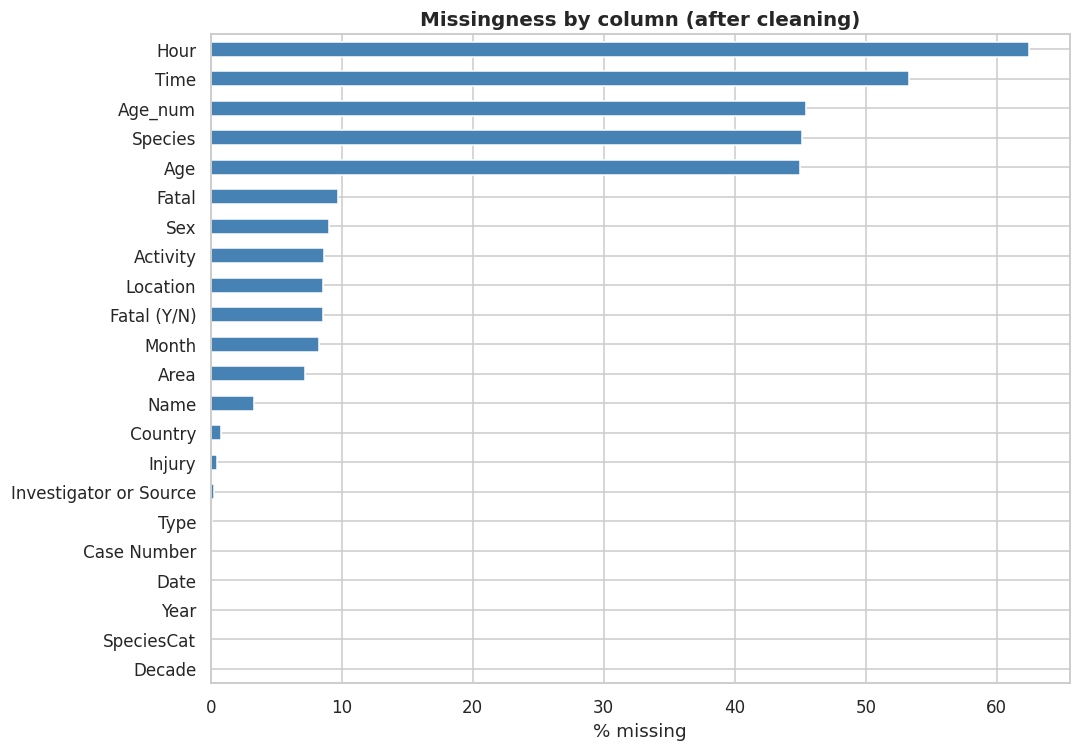

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
miss.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column (after cleaning)')
plt.tight_layout()
plt.show()

count    6300.0
mean     1927.3
std       281.1
min         0.0
25%      1942.0
50%      1977.0
75%      2005.0
max      2018.0
Name: Year, dtype: float64


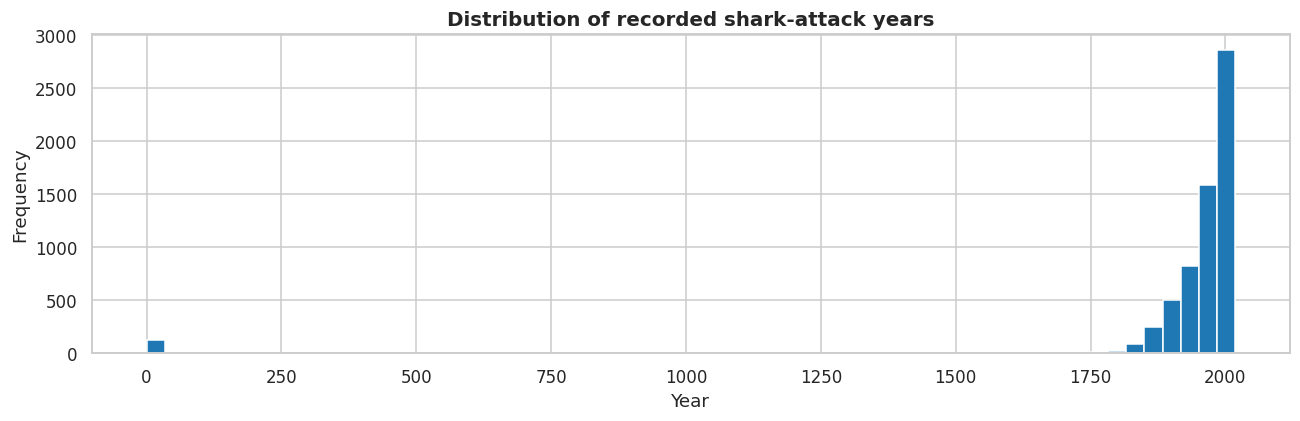

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
df['Year'].plot(kind='hist', bins=60, ax=ax, color='#1f77b4', edgecolor='white')
ax.set_xlabel('Year')
ax.set_title('Distribution of recorded shark-attack years')
plt.tight_layout()
plt.show()
print(df['Year'].describe().round(1))

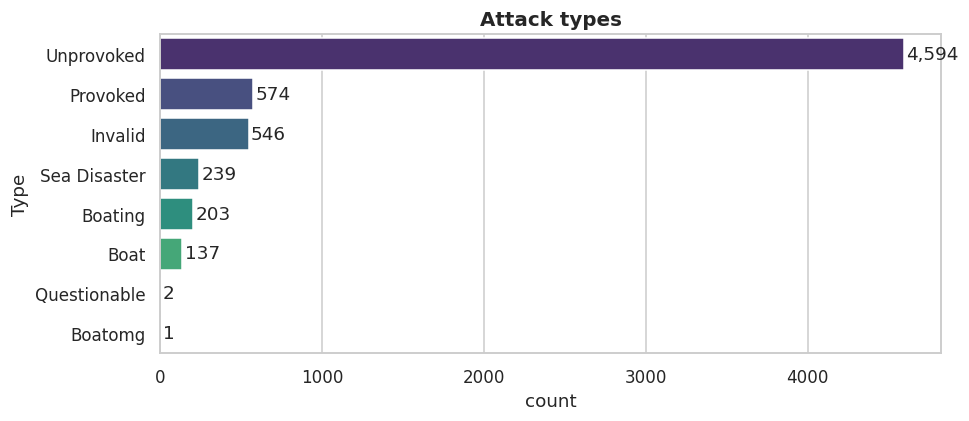

In [15]:
order = df['Type'].value_counts().index
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(y='Type', data=df, order=order, palette='viridis', ax=ax)
ax.set_title('Attack types')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width()+15, p.get_y()+p.get_height()/2), va='center')
plt.tight_layout()
plt.show()

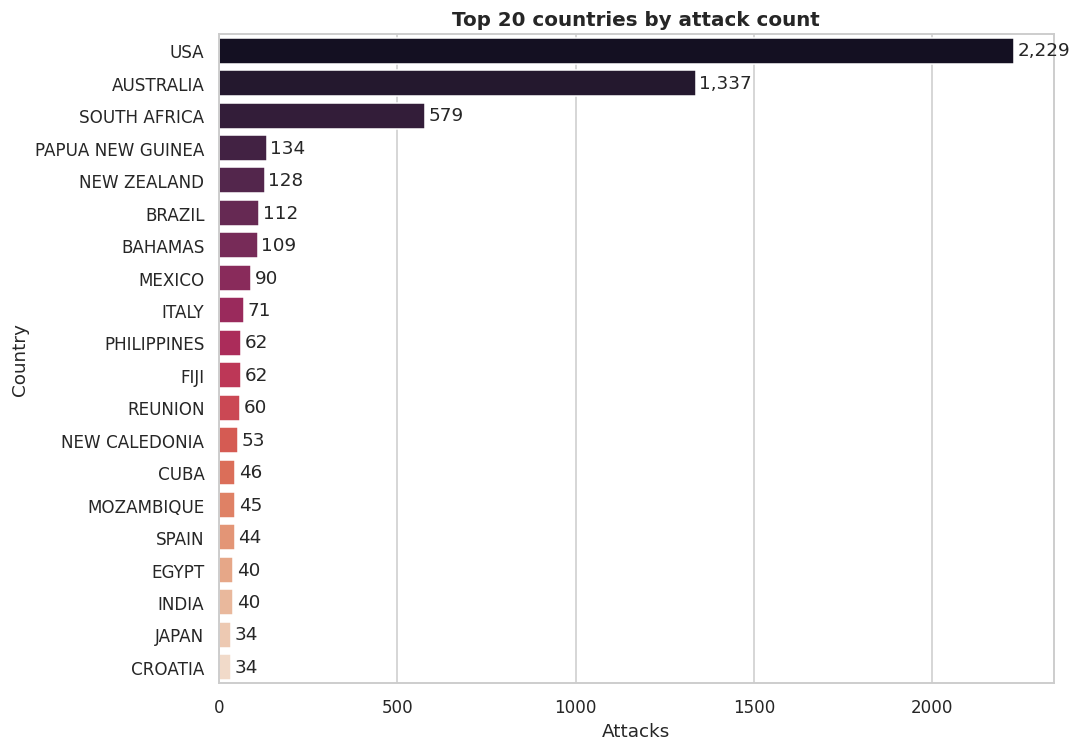

In [16]:
top_countries = df['Country'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket', ax=ax)
ax.set_title('Top 20 countries by attack count')
ax.set_xlabel('Attacks')
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

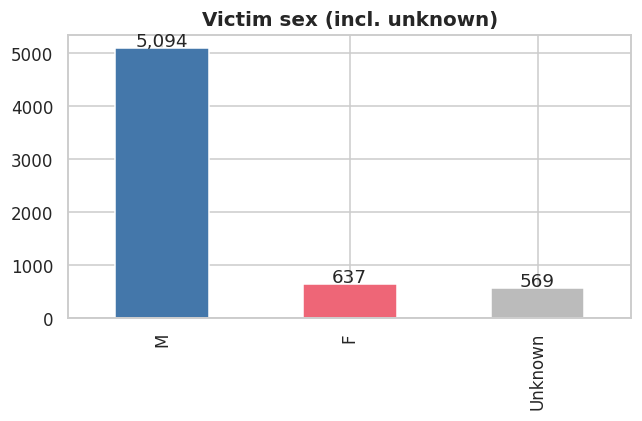

In [17]:
sex_counts = df['Sex'].value_counts(dropna=False)
sex_counts.index = sex_counts.index.fillna('Unknown') if hasattr(sex_counts.index, 'fillna') else ['M','F','Unknown']
fig, ax = plt.subplots(figsize=(6,4))
sex_counts.plot(kind='bar', ax=ax, color=['#4477AA', '#EE6677', '#BBBBBB'])
ax.set_title('Victim sex (incl. unknown)')
ax.set_xlabel('')
for i, v in enumerate(sex_counts.values):
    ax.text(i, v + 30, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

count    3440.0
mean       27.3
std        13.9
min         1.0
25%        17.0
50%        24.0
75%        35.0
max        87.0
Name: Age_num, dtype: float64


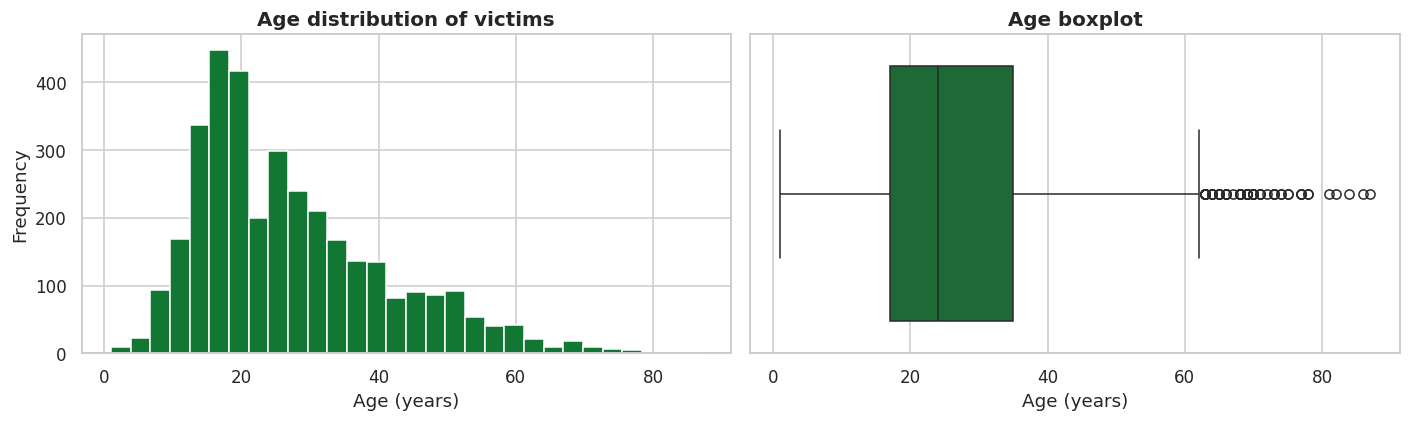

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['Age_num'].plot(kind='hist', bins=30, ax=axes[0], color='#117733', edgecolor='white')
axes[0].set_xlabel('Age (years)')
axes[0].set_title('Age distribution of victims')

sns.boxplot(x=df['Age_num'], ax=axes[1], color='#117733')
axes[1].set_xlabel('Age (years)')
axes[1].set_title('Age boxplot')
plt.tight_layout()
plt.show()
print(df['Age_num'].describe().round(1))

Among 5,689 cases with known outcome, fatality rate = 24.4%


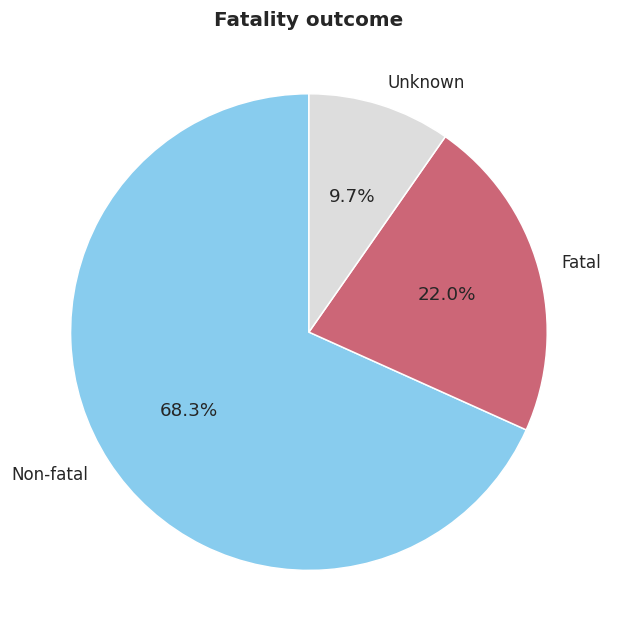

In [19]:
fatal_counts = df['Fatal'].value_counts(dropna=False)
labels = ['Non-fatal', 'Fatal', 'Unknown']
sizes = [fatal_counts.get('N', 0), fatal_counts.get('Y', 0), df['Fatal'].isna().sum()]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
       colors=['#88CCEE', '#CC6677', '#DDDDDD'])
ax.set_title('Fatality outcome')
plt.tight_layout()
plt.show()

known = df.dropna(subset=['Fatal'])
print(f'Among {len(known):,} cases with known outcome, fatality rate = {(known.Fatal=="Y").mean()*100:.1f}%')

Fatal,N,Y,Fatality rate %
Type,,,
Sea Disaster,66,168,71.8
Invalid,14,8,36.4
Unprovoked,3351,1180,26.0
Boating,189,7,3.6
Provoked,548,19,3.4
Boat,129,4,3.0
Boatomg,1,0,0.0
Questionable,2,0,0.0


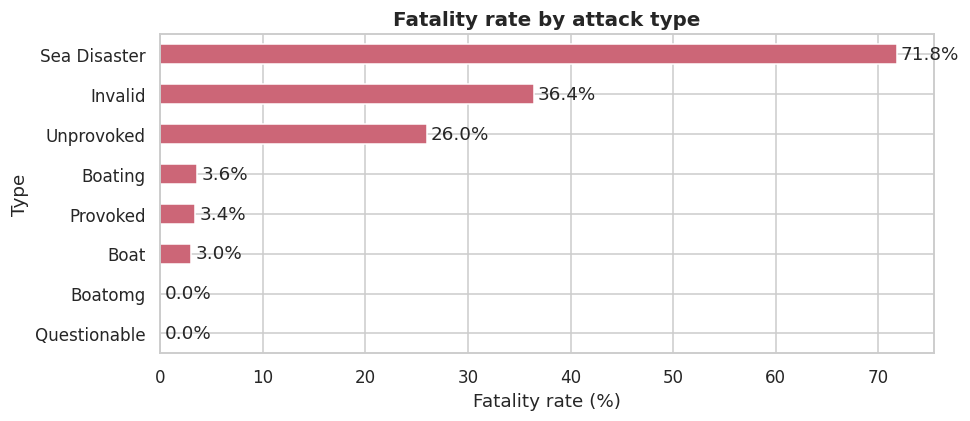

In [20]:
sub = df.dropna(subset=['Fatal', 'Type'])
ct = pd.crosstab(sub['Type'], sub['Fatal'])
ct['Fatality rate %'] = (ct.get('Y', 0) / ct.sum(axis=1) * 100).round(1)
ct = ct.sort_values('Fatality rate %', ascending=False)
display(ct)

fig, ax = plt.subplots(figsize=(9, 4))
ct['Fatality rate %'].plot(kind='barh', ax=ax, color='#CC6677')
ax.invert_yaxis()
ax.set_xlabel('Fatality rate (%)')
ax.set_title('Fatality rate by attack type')
for i, v in enumerate(ct['Fatality rate %'].values):
    ax.text(v + 0.4, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

,N %,Y %
Sex,,
F,81.4,18.6
M,74.8,25.2


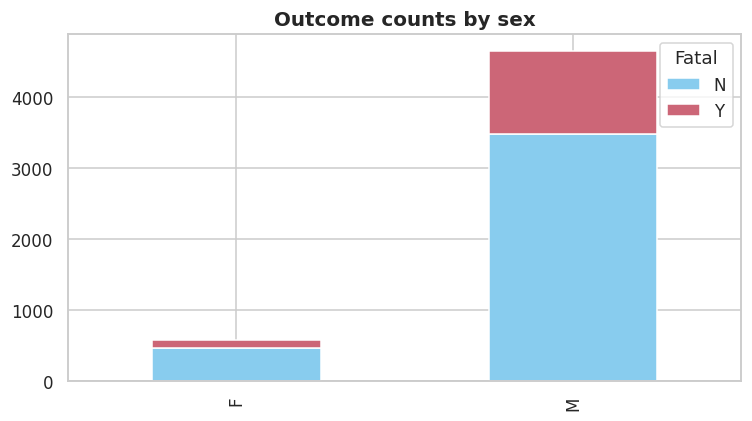

In [21]:
sub = df.dropna(subset=['Fatal', 'Sex'])
ct = pd.crosstab(sub['Sex'], sub['Fatal'], normalize='index') * 100
ct.columns = [f'{c} %' for c in ct.columns]
display(ct.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
pd.crosstab(sub['Sex'], sub['Fatal']).plot(kind='bar', stacked=True,
                                            color=['#88CCEE','#CC6677'], ax=ax)
ax.set_title('Outcome counts by sex')
ax.set_xlabel('')
ax.legend(title='Fatal')
plt.tight_layout()
plt.show()

,n,fatal_pct
AgeGroup,,
0-12,265.0,15.1
13-18,745.0,20.7
19-30,1165.0,20.1
31-45,645.0,17.2
46-60,304.0,16.1
60+,79.0,29.1


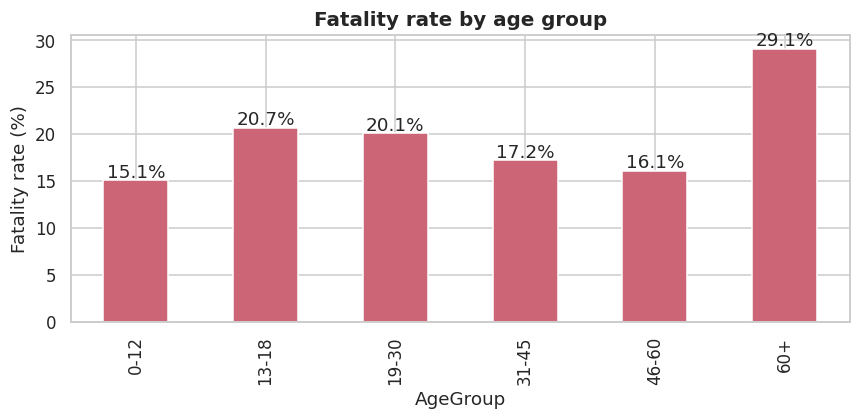

In [22]:
bins = [0, 12, 18, 30, 45, 60, 100]
labels = ['0-12', '13-18', '19-30', '31-45', '46-60', '60+']
sub = df.dropna(subset=['Age_num', 'Fatal']).copy()
sub['AgeGroup'] = pd.cut(sub['Age_num'], bins=bins, labels=labels, include_lowest=True)

ct = sub.groupby('AgeGroup').apply(
    lambda g: pd.Series({
        'n': len(g),
        'fatal_pct': (g['Fatal']=='Y').mean() * 100
    })
)
display(ct.round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ct['fatal_pct'].plot(kind='bar', ax=ax, color='#CC6677')
ax.set_ylabel('Fatality rate (%)')
ax.set_title('Fatality rate by age group')
for i, v in enumerate(ct['fatal_pct'].values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

,n,fatal_pct
Country,,
USA,2023.0,9.2
AUSTRALIA,1204.0,23.5
SOUTH AFRICA,513.0,20.7
PAPUA NEW GUINEA,130.0,43.1
NEW ZEALAND,115.0,20.9
BAHAMAS,104.0,9.6
BRAZIL,102.0,37.3
MEXICO,79.0,54.4
PHILIPPINES,57.0,63.2


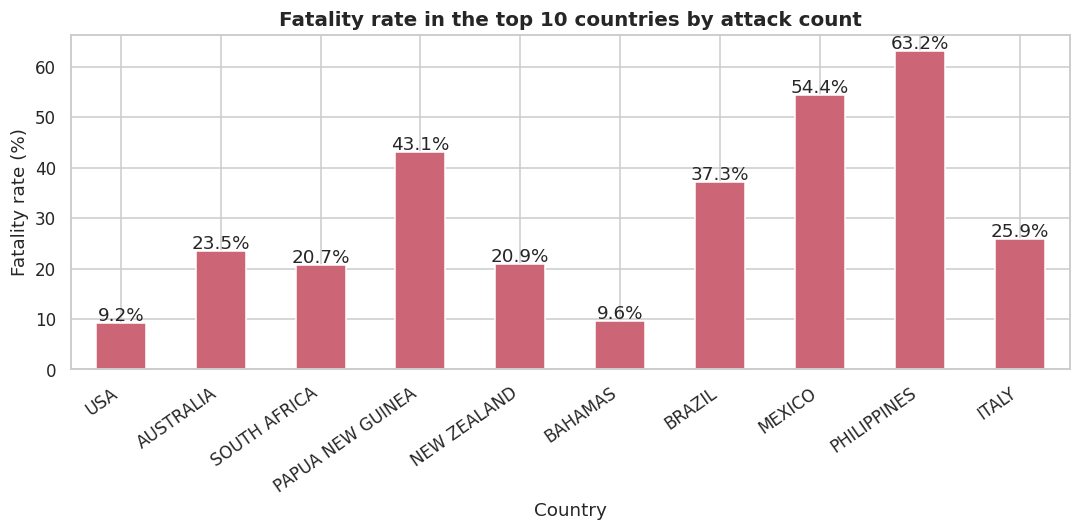

In [23]:
topN = 10
top_c = df['Country'].value_counts().head(topN).index
sub = df[df['Country'].isin(top_c)].dropna(subset=['Fatal'])
ct = sub.groupby('Country').apply(
    lambda g: pd.Series({
        'n': len(g),
        'fatal_pct': (g['Fatal']=='Y').mean() * 100
    })
).sort_values('n', ascending=False)
display(ct.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
ct['fatal_pct'].plot(kind='bar', ax=ax, color='#CC6677')
ax.set_ylabel('Fatality rate (%)')
ax.set_title(f'Fatality rate in the top {topN} countries by attack count')
for i, v in enumerate(ct['fatal_pct'].values):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

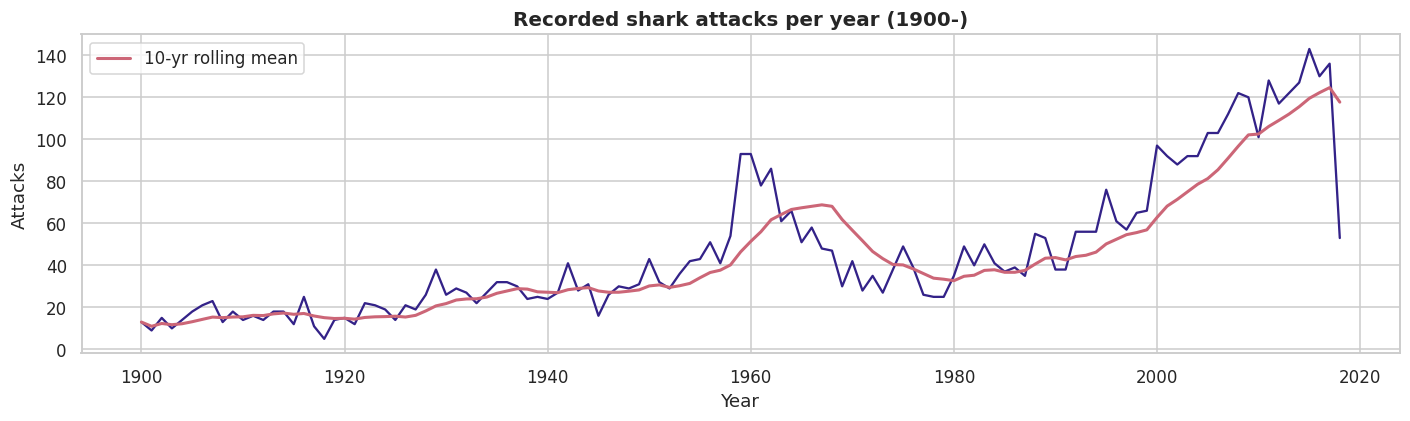

In [24]:
yearly = df[df['Year'] >= 1900].groupby('Year').size()
fig, ax = plt.subplots(figsize=(13, 4))
yearly.plot(ax=ax, color='#332288')
yearly.rolling(10, min_periods=1).mean().plot(ax=ax, color='#CC6677', linewidth=2, label='10-yr rolling mean')
ax.set_title('Recorded shark attacks per year (1900-)')
ax.set_ylabel('Attacks')
ax.legend()
plt.tight_layout()
plt.show()

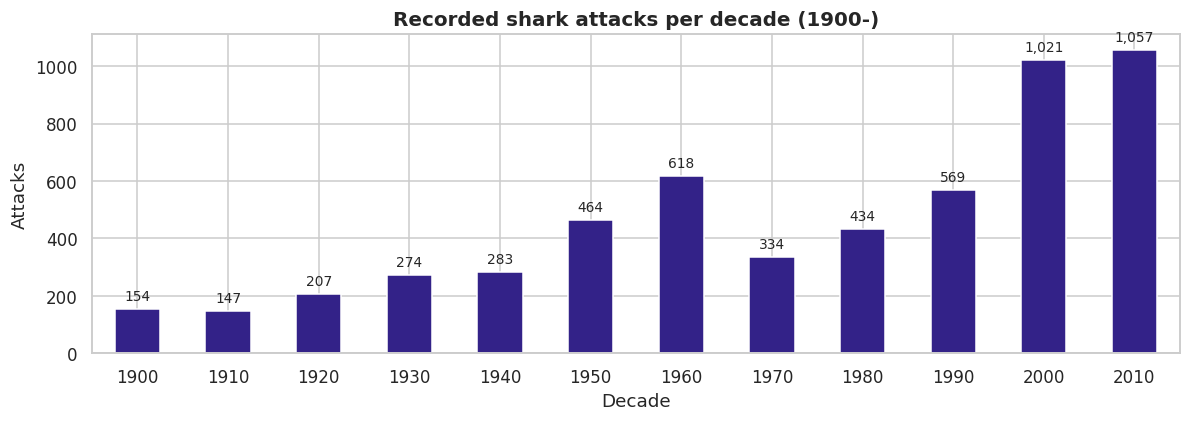

In [25]:
decade = df[df['Year'] >= 1900].groupby('Decade').size()
fig, ax = plt.subplots(figsize=(11, 4))
decade.plot(kind='bar', ax=ax, color='#332288')
ax.set_title('Recorded shark attacks per decade (1900-)')
ax.set_ylabel('Attacks')
for i, v in enumerate(decade.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

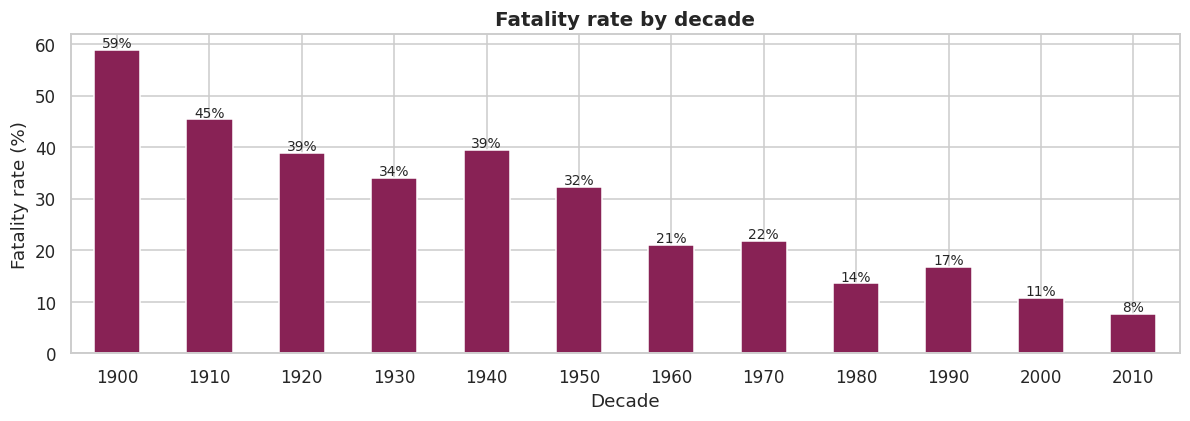

In [26]:
sub = df[(df['Year'] >= 1900) & df['Fatal'].notna()].copy()
fatality_decade = sub.groupby('Decade').apply(lambda g: (g['Fatal']=='Y').mean() * 100)

fig, ax = plt.subplots(figsize=(11, 4))
fatality_decade.plot(kind='bar', ax=ax, color='#882255')
ax.set_title('Fatality rate by decade')
ax.set_ylabel('Fatality rate (%)')
for i, v in enumerate(fatality_decade.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

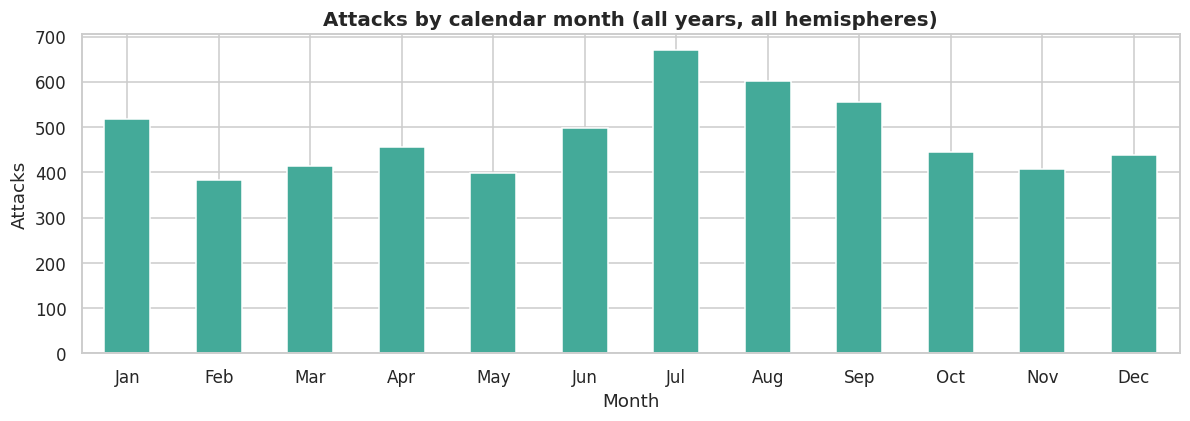

In [27]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['Month'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 4))
month_counts.plot(kind='bar', ax=ax, color='#44AA99')
ax.set_title('Attacks by calendar month (all years, all hemispheres)')
ax.set_ylabel('Attacks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

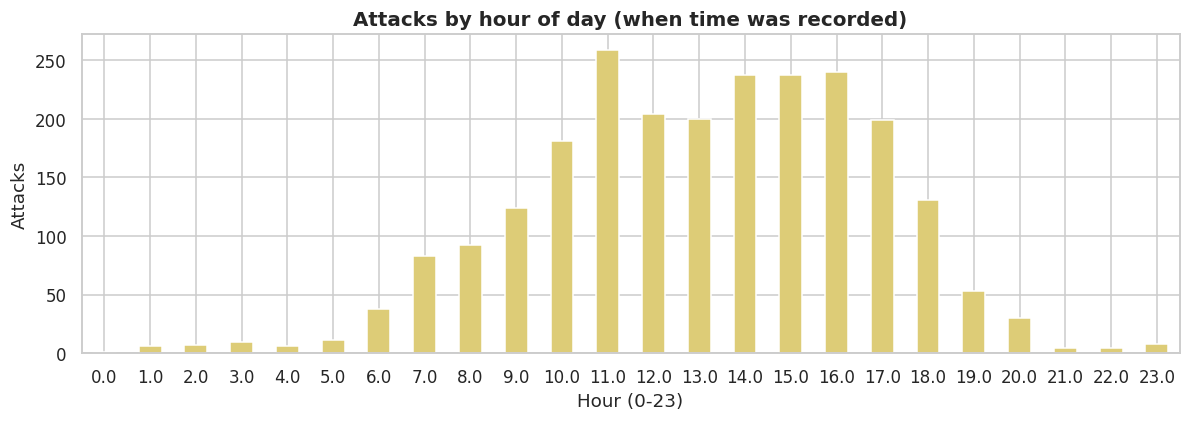

In [28]:
hour_counts = df['Hour'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
hour_counts.plot(kind='bar', ax=ax, color='#DDCC77')
ax.set_title('Attacks by hour of day (when time was recorded)')
ax.set_xlabel('Hour (0-23)')
ax.set_ylabel('Attacks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

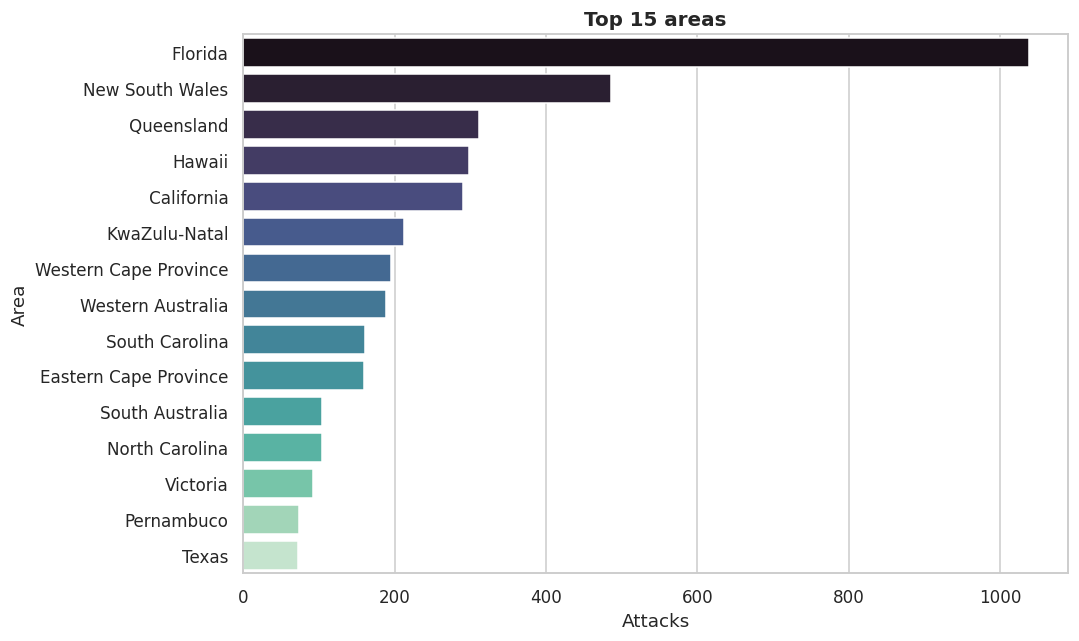

In [29]:
top_areas = df['Area'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_areas.values, y=top_areas.index, palette='mako', ax=ax)
ax.set_title('Top 15 areas')
ax.set_xlabel('Attacks')
plt.tight_layout()
plt.show()

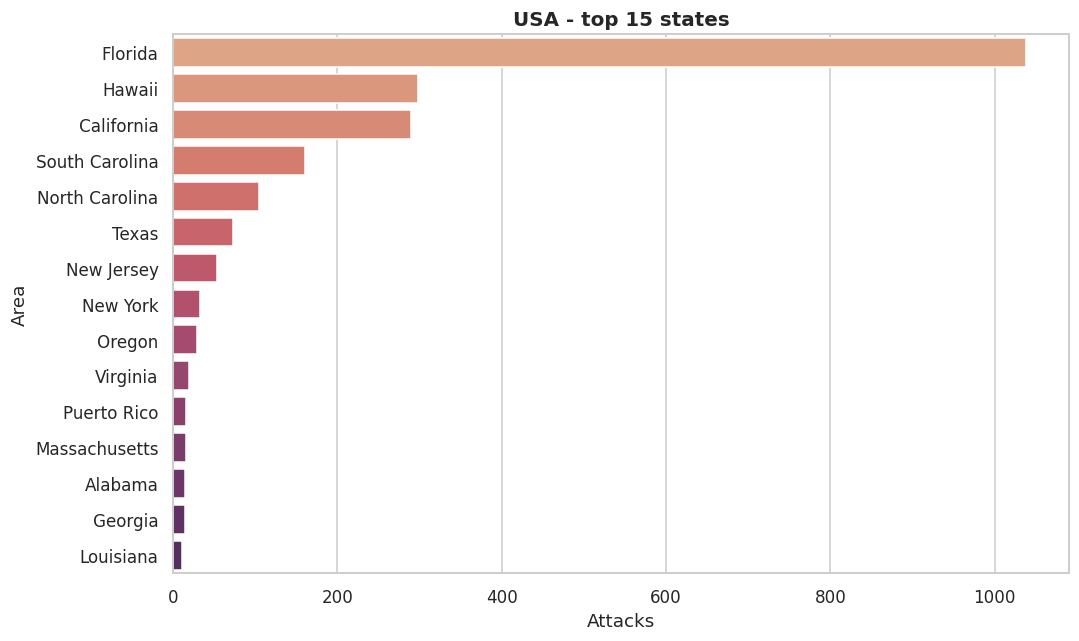

In [30]:
usa = df[df['Country'] == 'USA']
usa_state = usa['Area'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=usa_state.values, y=usa_state.index, palette='flare', ax=ax)
ax.set_title('USA - top 15 states')
ax.set_xlabel('Attacks')
plt.tight_layout()
plt.show()

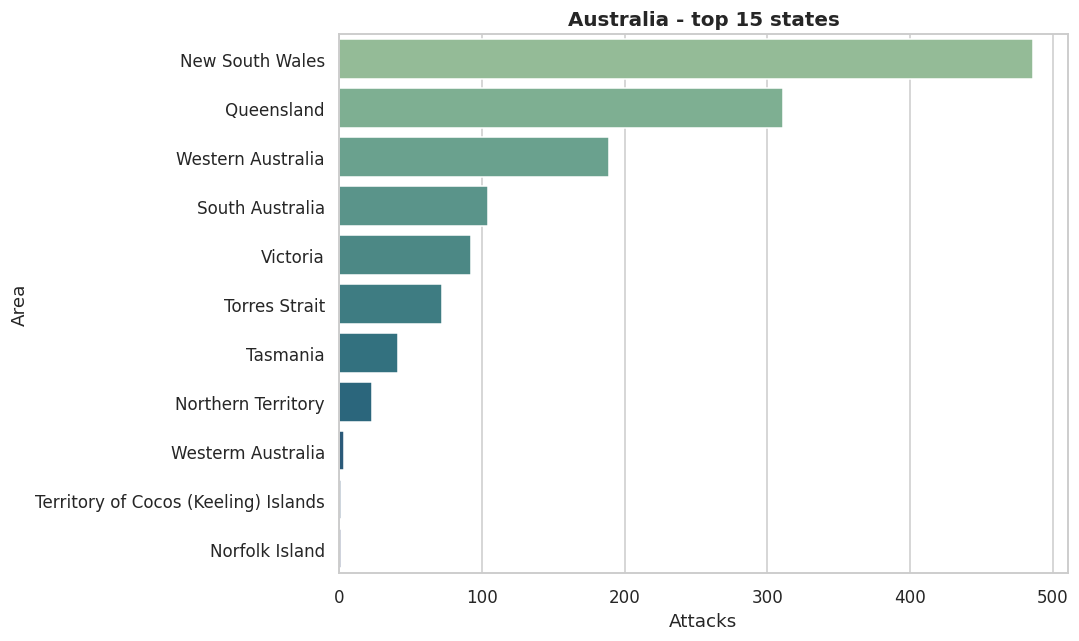

In [31]:
aus = df[df['Country'] == 'AUSTRALIA']
aus_state = aus['Area'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=aus_state.values, y=aus_state.index, palette='crest', ax=ax)
ax.set_title('Australia - top 15 states')
ax.set_xlabel('Attacks')
plt.tight_layout()
plt.show()

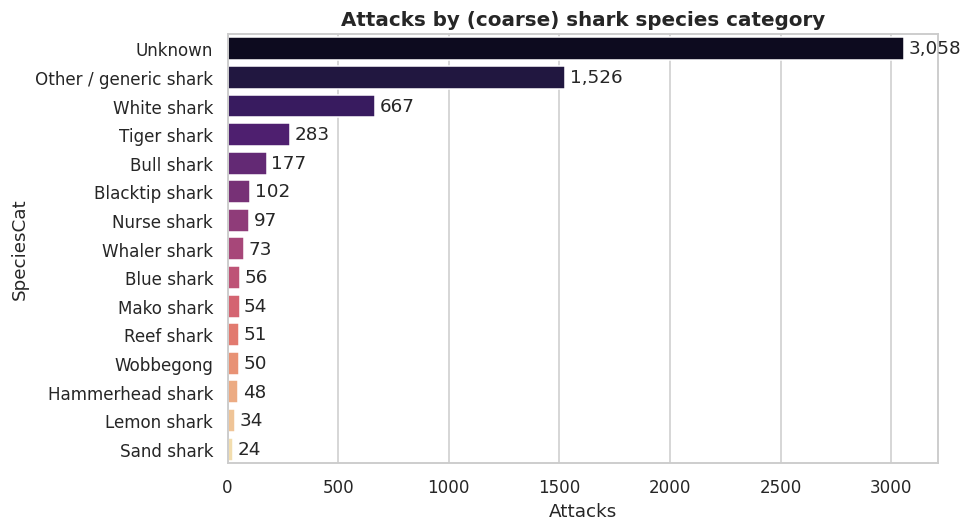

In [32]:
spec = df['SpeciesCat'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=spec.values, y=spec.index, palette='magma', ax=ax)
ax.set_title('Attacks by (coarse) shark species category')
ax.set_xlabel('Attacks')
for i, v in enumerate(spec.values):
    ax.text(v + 20, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

,n,fatal_pct
SpeciesCat,,
Other / generic shark,1192.0,11.7
White shark,653.0,23.0
Tiger shark,279.0,25.8
Bull shark,177.0,20.3
Blacktip shark,102.0,0.0
Nurse shark,96.0,1.0
Whaler shark,72.0,8.3
Blue shark,54.0,20.4
Mako shark,54.0,3.7


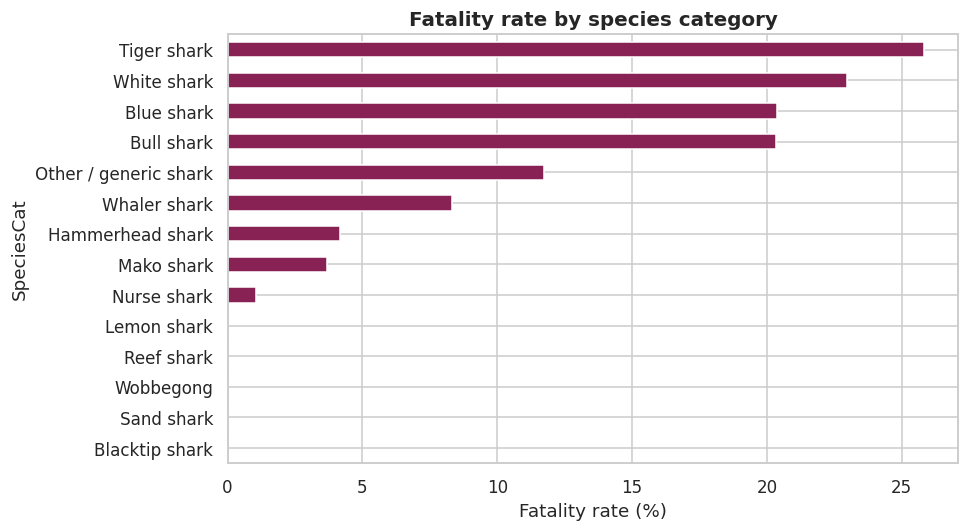

In [33]:
sub = df.dropna(subset=['Fatal'])
sub = sub[sub['SpeciesCat'] != 'Unknown']
spec_fatal = sub.groupby('SpeciesCat').apply(
    lambda g: pd.Series({
        'n': len(g),
        'fatal_pct': (g['Fatal']=='Y').mean() * 100
    })
).sort_values('n', ascending=False)
display(spec_fatal.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
spec_fatal.sort_values('fatal_pct')['fatal_pct'].plot(kind='barh', ax=ax, color='#882255')
ax.set_title('Fatality rate by species category')
ax.set_xlabel('Fatality rate (%)')
plt.tight_layout()
plt.show()

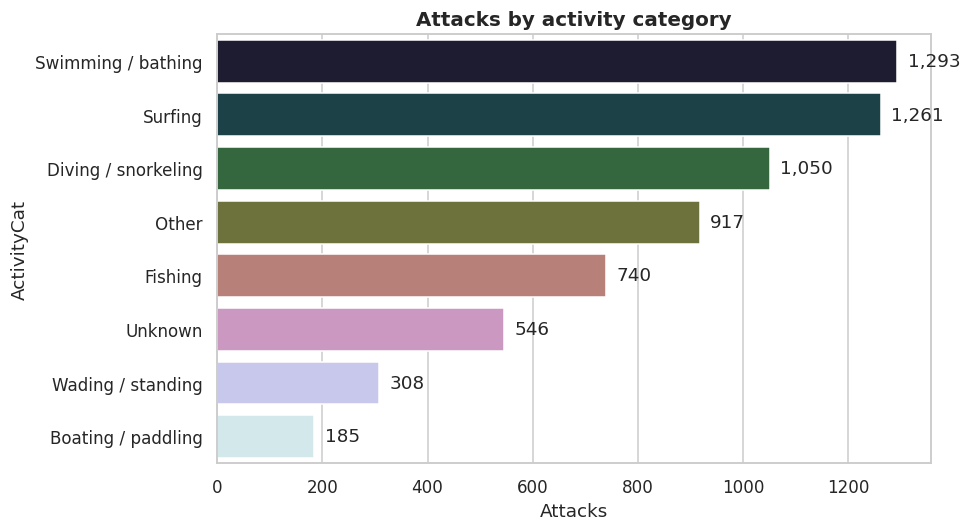

In [34]:
def normalize_activity(a):
    if pd.isna(a):
        return 'Unknown'
    a = str(a).lower()
    if any(k in a for k in ['surf']):
        return 'Surfing'
    if any(k in a for k in ['swim', 'bathing']):
        return 'Swimming / bathing'
    if any(k in a for k in ['div', 'snorkel', 'spearfish']):
        return 'Diving / snorkeling'
    if any(k in a for k in ['fish']):
        return 'Fishing'
    if any(k in a for k in ['wading', 'standing', 'walking']):
        return 'Wading / standing'
    if any(k in a for k in ['kayak', 'canoe', 'paddl', 'boat']):
        return 'Boating / paddling'
    return 'Other'

df['ActivityCat'] = df['Activity'].apply(normalize_activity)

act_counts = df['ActivityCat'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=act_counts.values, y=act_counts.index, palette='cubehelix', ax=ax)
ax.set_title('Attacks by activity category')
ax.set_xlabel('Attacks')
for i, v in enumerate(act_counts.values):
    ax.text(v + 20, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

,n,fatal_pct
ActivityCat,,
Swimming / bathing,1164.0,42.9
Other,826.0,37.9
Boating / paddling,163.0,33.7
Diving / snorkeling,951.0,20.7
Fishing,699.0,14.6
Wading / standing,292.0,14.4
Surfing,1208.0,6.1


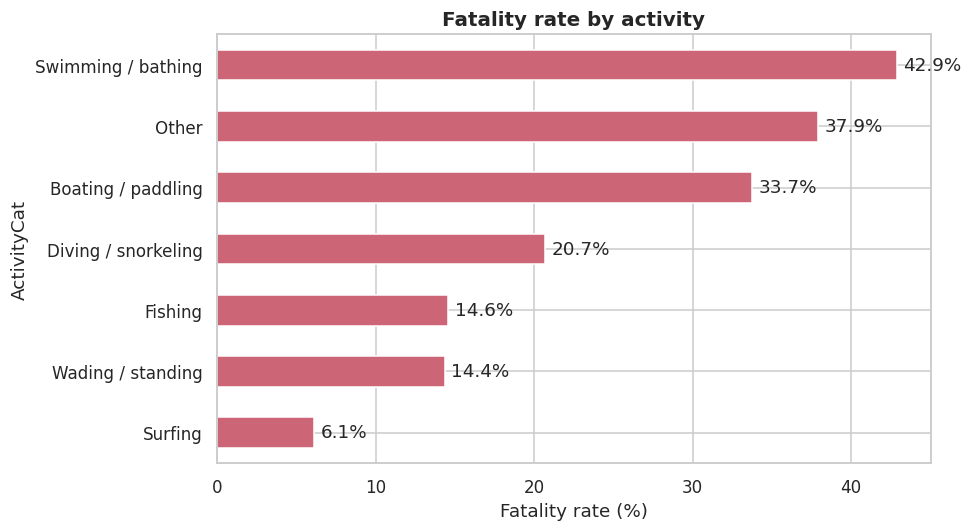

In [35]:
sub = df.dropna(subset=['Fatal'])
sub = sub[sub['ActivityCat'] != 'Unknown']
act_fatal = sub.groupby('ActivityCat').apply(
    lambda g: pd.Series({
        'n': len(g),
        'fatal_pct': (g['Fatal']=='Y').mean() * 100
    })
).sort_values('fatal_pct', ascending=False)
display(act_fatal.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
act_fatal['fatal_pct'].plot(kind='barh', ax=ax, color='#CC6677')
ax.invert_yaxis()
ax.set_title('Fatality rate by activity')
ax.set_xlabel('Fatality rate (%)')
for i, v in enumerate(act_fatal['fatal_pct'].values):
    ax.text(v + 0.4, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

      count  mean   std  min   25%   50%   75%   max
Sex                                                 
F     459.0  26.7  16.4  1.0  14.0  21.0  37.0  77.0
M    2943.0  27.5  13.5  1.0  17.0  24.0  35.0  87.0


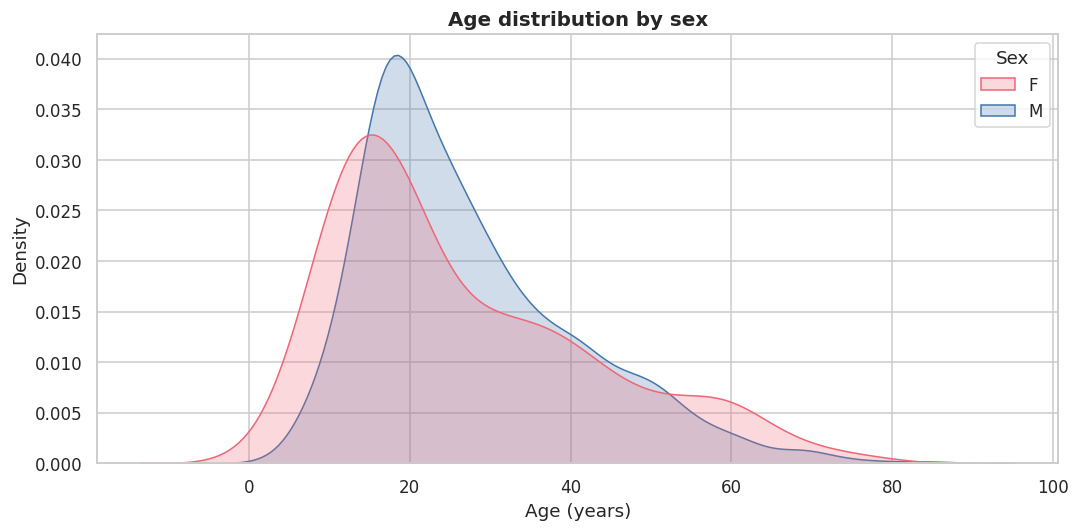

In [36]:
sub = df.dropna(subset=['Age_num', 'Sex'])
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=sub, x='Age_num', hue='Sex', fill=True, common_norm=False,
            palette={'M':'#4477AA','F':'#EE6677'}, ax=ax)
ax.set_title('Age distribution by sex')
ax.set_xlabel('Age (years)')
plt.tight_layout()
plt.show()
print(sub.groupby('Sex')['Age_num'].describe().round(1))

        count  mean   std  min   25%   50%   75%   max
Fatal                                                 
N      2592.0  27.3  13.7  3.0  17.0  24.0  35.0  87.0
Y       611.0  27.0  14.3  1.0  17.0  22.0  33.0  84.0


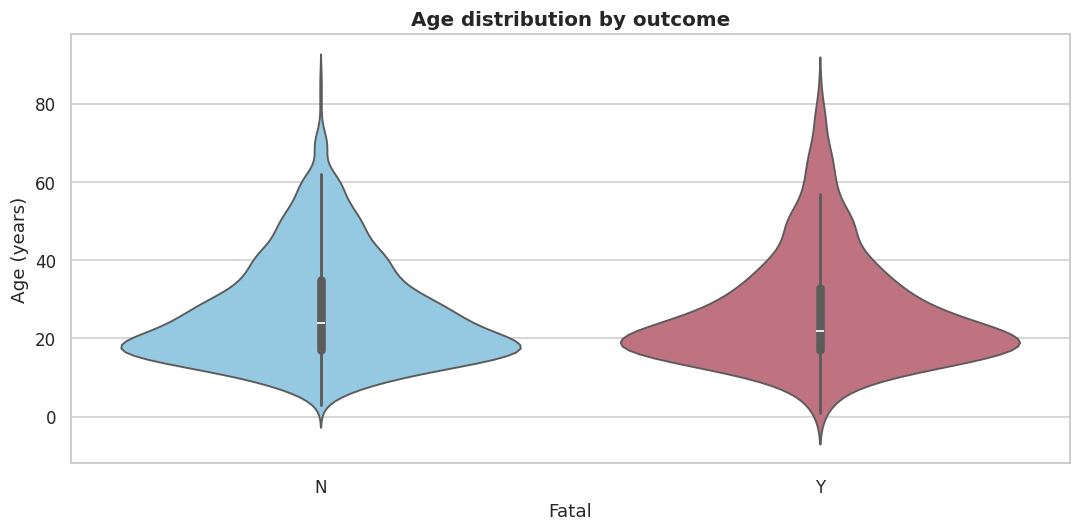

In [37]:
sub = df.dropna(subset=['Age_num', 'Fatal'])
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=sub, x='Fatal', y='Age_num',
               palette={'N':'#88CCEE','Y':'#CC6677'}, ax=ax)
ax.set_title('Age distribution by outcome')
ax.set_ylabel('Age (years)')
ax.set_xlabel('Fatal')
plt.tight_layout()
plt.show()
print(sub.groupby('Fatal')['Age_num'].describe().round(1))

,word,count
0,bitten,1569
1,fatal,1359
2,shark,1350
3,injury,969
4,right,846
5,left,841
6,foot,791
7,lacerations,601
8,provoked,573
9,incident,572


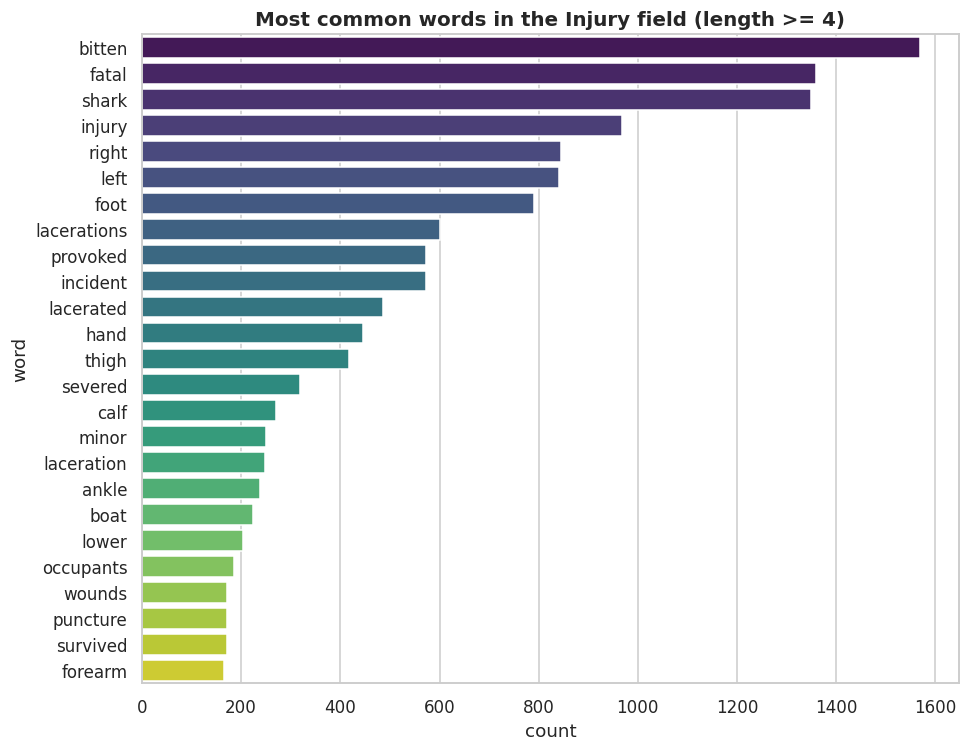

In [ ]:
STOP = set('''a an and or the to of in on at from for by with as into onto upon over under up down off
out is was were be been being it its his her she he they them their his hers him this that those these
who whom which what when where why how but not no nor so than then if there here also very while during
much more most some any all every each both few many other another own such same other only just before
after again about along among around between because cannot could would should may might shall will'''.split())

WORD = re.compile(r'[a-zA-Z]{4,}')
def tokens(s):
    if pd.isna(s):
        return []
    return [t.lower() for t in WORD.findall(s) if t.lower() not in STOP]

all_tokens = []
for s in df['Injury'].dropna():
    all_tokens.extend(tokens(s))

top_words = Counter(all_tokens).most_common(25)
words_df = pd.DataFrame(top_words, columns=['word', 'count'])
display(words_df)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x='count', y='word', data=words_df, palette='viridis', ax=ax)
ax.set_title('Most common words in the Injury field (length >= 4)')
plt.tight_layout()
plt.show()